## Abhirup Basu - 250107003 

In [1420]:
#NOTE : The report is written at last

### Importing libraries

In [1377]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1378]:
# Rest i'll import when needed

### Importing datasets

In [1379]:
# Converting the excel files to csv for easier workflow

In [1380]:
df1 = pd.read_excel("PGCB_date_power_demand.xlsx")
df1.to_csv("PGCB_date_power_demand.csv", index=False)
#df11 = pd.read_csv("PGCB_date_power_demand.csv")
demand_df = df1
#demand_df.head(1)
demand_df.shape
## i mistakely deleted the xlsx files so i have commented out these statements


(92650, 15)

In [1381]:
df2 = pd.read_excel("weather_data.xlsx", skiprows=3)
df2.to_csv("weather_data.csv", index=False)
#df22 = pd.read_csv('weather_data.csv',skiprows=3) #till row 3, probably metadata exiset
weather_df = df2
#weather_df.head(1)
weather_df.shape

(107304, 10)

In [1382]:
df33 = pd.read_csv('economic_full_1.csv')
econ_df = df33
#econ_df.head(1)
# eta transpos kora ache

In [1383]:
#this column contains many features which i dont thnik are useful
## earlier the  ....... were appearing due to string limit so i did this 
#pd.set_option('display.max_colwidth', None)
#print(econ_df['Indicator Name'].to_string())
print(weather_df.columns)

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)'],
      dtype='object')


## Data Preprocessing

In [1384]:
economic_df = econ_df
## according to me things like Population ages 60-64, male (% of male population) dont have any impact on the outcome those i thought had
## i included these 20 features manually from the given 1.5k features in econ df
relevant_indicators = [
    'GDP (current US$)',      #----------------------------------------------------- 1                    
   'GDP growth (annual %)',         #-----------------------------------------------------  2           
    'Access to electricity (% of population)',   #----------------------------------------------------- 3 
    'Electric power consumption (kWh per capita)',#----------------------------------------------------- 4
    'Population, total',                 #-----------------------------------------------------       5  
    'Urban population',   #-----------------------------------------------------                       6 
    'Inflation, consumer prices (annual %)',      #-----------------------------------------------------7
    'Energy use (kg of oil equivalent per capita)',#-----------------------------------------------------8
    'Fossil fuel energy consumption (% of total)', #-----------------------------------------------------9
    'Industry (including construction), value added (% of GDP)',#----------------------------------------------------- 10
    'Electricity production from renewable sources, excluding hydroelectric (kWh)',#----------------------------------------------------- 11 
    'Electricity production from natural gas sources (% of total)',#----------------------------------------------------- 12
    'Electricity production from coal sources (% of total)', #----------------------------------------------------- 13 
    'Value lost due to electrical outages (% of sales for affected firms)', #-----------------------------------------------------  14
    'Electricity production from renewable sources, excluding hydroelectric (% of total)',#----------------------------------------------------- 15
    'Electricity production from nuclear sources (% of total)',#----------------------------------------------------- 16
    'Electricity production from oil, gas and coal sources (% of total)',#----------------------------------------------------- 17
    'Access to electricity, rural (% of rural population)',#----------------------------------------------------- 18
    'Electricity production from oil sources (% of total)', #----------------------------------------------------- 19
    'Electricity production from hydroelectric sources (% of total)',#----------------------------------------------------- 20

]

eco_filtered = economic_df[economic_df['Indicator Name'].isin(relevant_indicators)]

#Transposed so that rows become years, columns become indicators
year_cols = [str(y) for y in range(2015, 2026)]  #acc. to pcb data

eco_transposed = (
    eco_filtered
    .set_index('Indicator Name')[year_cols]
    .T
    .reset_index()
    .rename(columns={'index': 'year'})
)
eco_transposed['year'] = eco_transposed['year'].astype(int)

print(eco_transposed.shape) ## no. of rows == 11 == 2026 - 2015. So transpose has taken place correctly

(11, 21)


In [1385]:
#This is a necessary step which ensures the functions i'll implement later donot give any problem
demand_df['timestamp'] = pd.to_datetime(demand_df['datetime'])
weather_df['timestamp'] = (pd.to_datetime(weather_df['time'], utc=True)
                             .dt.tz_convert('Asia/Dhaka')
                             .dt.tz_localize(None))

In [1386]:
demand_df.duplicated().sum() #!!Duplicates found

np.int64(160)

In [1387]:
weather_df.duplicated().sum() #No dup found

np.int64(0)

In [1388]:
eco_transposed.duplicated().sum() #No dup found

np.int64(0)

In [1389]:
# i see that there are duplicates in this df so i drop it before any merge since 92650 >> 160
demand_df = demand_df.sort_values('timestamp').drop_duplicates(subset='timestamp', keep='first')

In [1390]:
 #Calculating time difference between consecutive rows
demand_df_sorted = demand_df.sort_values('timestamp')
time_diffs = demand_df_sorted['timestamp'].diff()

 #What gap sizes exist?

print(time_diffs.value_counts().sort_index())
## Many irregular timestamp frequency exists

timestamp
0 days 00:30:00      8336
0 days 01:00:00     83649
0 days 01:30:00         8
0 days 02:00:00       178
0 days 03:00:00        11
0 days 04:00:00         2
0 days 05:00:00         1
0 days 06:00:00         1
0 days 07:00:00         4
0 days 08:00:00         3
0 days 09:00:00         4
0 days 10:00:00         4
0 days 11:00:00         4
0 days 12:00:00         4
0 days 13:00:00         3
0 days 15:00:00         1
0 days 19:00:00         1
1 days 01:00:00         1
1 days 03:00:00         1
21 days 14:00:00        1
Name: count, dtype: int64


In [1391]:
# We floor everything to the hour (e.g., 10:30 becomes 10:00)
demand_df['hour_bin'] = demand_df['timestamp'].dt.floor('H')

numeric_cols = [
    'generation_mw', 'demand_mw', 'load_shedding', 
    'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal'
]

existing_numeric = [c for c in numeric_cols if c in demand_df.columns]

demand_df_hourly = demand_df.groupby('hour_bin')[existing_numeric].mean().reset_index()
demand_df_hourly = demand_df_hourly.rename(columns={'hour_bin': 'timestamp'})

full_range = pd.date_range(
    start=demand_df_hourly['timestamp'].min(), 
    end=demand_df_hourly['timestamp'].max(), 
    freq='1H'
)

demand_df_clean = demand_df_hourly.set_index('timestamp').reindex(full_range)

demand_df_clean = demand_df_clean.ffill().reset_index()
demand_df_clean = demand_df_clean.rename(columns={'index': 'timestamp'})

print("New Timestamp Gaps:")
print(demand_df_clean['timestamp'].diff().value_counts())

demand_df = demand_df_clean

New Timestamp Gaps:
timestamp
0 days 01:00:00    89100
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_17256\4100124036.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  demand_df['hour_bin'] = demand_df['timestamp'].dt.floor('H')
C:\Users\User\AppData\Local\Temp\ipykernel_17256\4100124036.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(


In [1392]:


# Merge demand + weather dataframes
merged_df = pd.merge(demand_df, weather_df, on='timestamp', how='inner')

# Reshape + merge economic dataframe
merged_df['year'] = merged_df['timestamp'].dt.year
merged_df = pd.merge(merged_df, eco_transposed, on='year', how='left')


print(merged_df.shape)


(89101, 45)


In [1393]:
#merged_df.head()

In [1394]:
# Finding which demand timestamps have no match in weather
unmatched = demand_df[~demand_df['timestamp'].isin(weather_df['timestamp'])]
print(f"Unmatched rows: {len(unmatched)}")
print(unmatched['timestamp'].dt.year.value_counts().sort_index())

Unmatched rows: 0
Series([], Name: count, dtype: int64)


In [1395]:
weather_df['hour'] = pd.to_datetime(weather_df['time']).dt.hour
print(weather_df['hour'].value_counts().sort_index())
#Perfect

hour
0     4471
1     4471
2     4471
3     4471
4     4471
5     4471
6     4471
7     4471
8     4471
9     4471
10    4471
11    4471
12    4471
13    4471
14    4471
15    4471
16    4471
17    4471
18    4471
19    4471
20    4471
21    4471
22    4471
23    4471
Name: count, dtype: int64


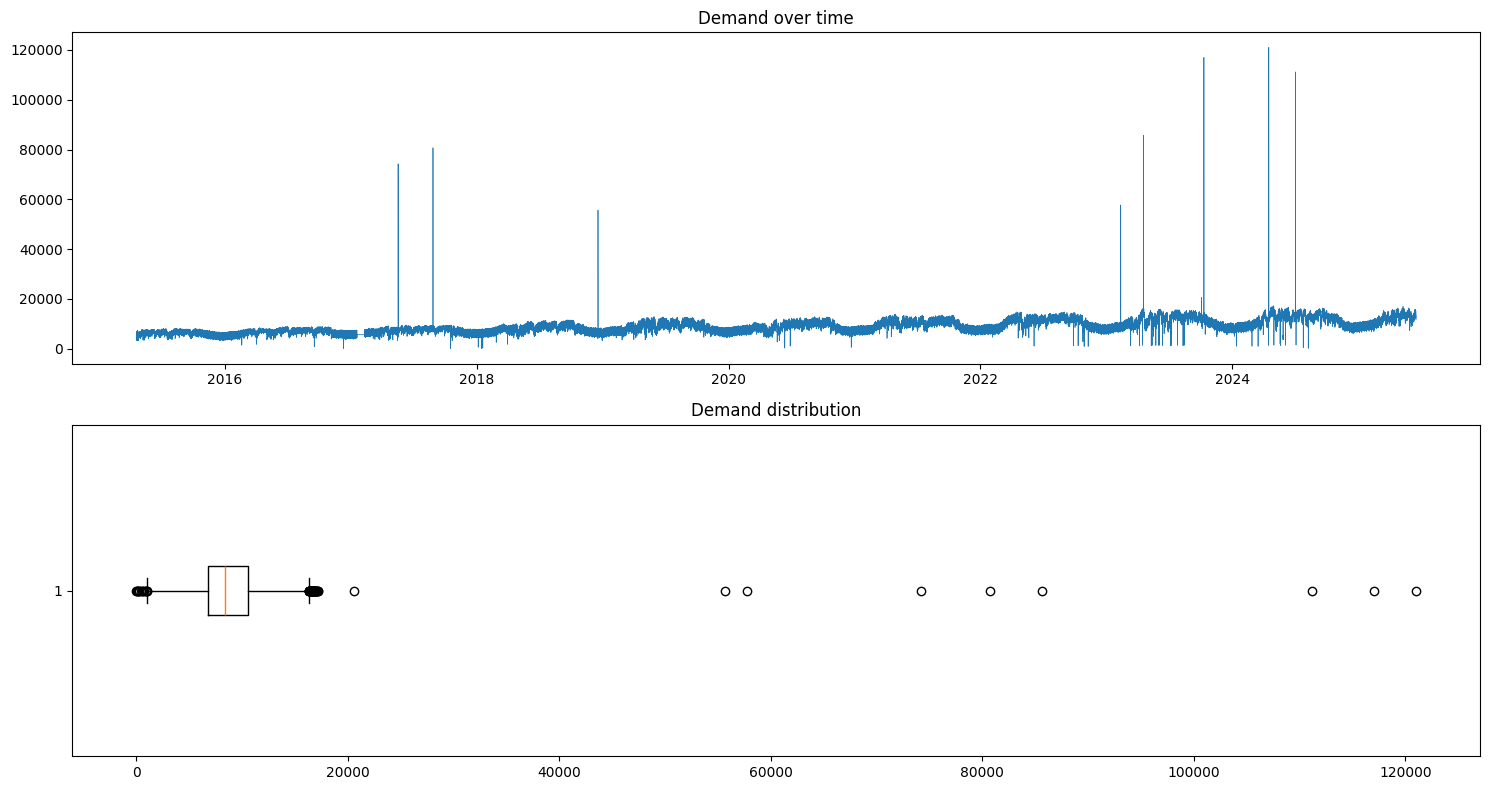

In [1396]:

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# time vs demand plot
axes[0].plot(merged_df['timestamp'], merged_df['demand_mw'], linewidth=0.5)
axes[0].set_title('Demand over time')

# Box plot --- to show outliers
axes[1].boxplot(merged_df['demand_mw'].dropna(), vert=False)
axes[1].set_title('Demand distribution')

plt.tight_layout()
plt.show()

In [1397]:
## Clear spikez are visible

In [1398]:
## i am using z score
# How many standard deviations is each point from its local mean?
rolling_mean = merged_df['demand_mw'].rolling(window=24*7, center=True).mean()
rolling_std = merged_df['demand_mw'].rolling(window=24*7, center=True).std()

merged_df['zscore'] = (merged_df['demand_mw'] - rolling_mean) / rolling_std

outliers = merged_df[merged_df['zscore'].abs() > 3]
print(f"Outliers detected: {len(outliers)}")

Outliers detected: 84


In [1399]:
## i will use interpolation but removing is also fine ig. ps says to handle
Q1 = merged_df['demand_mw'].quantile(0.25)
Q3 = merged_df['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
merged_df.loc[(merged_df['demand_mw'] < lower) | (merged_df['demand_mw'] > upper), 'demand_mw'] = np.nan

print(f"NaNs in demand_mw: {merged_df['demand_mw'].isnull().sum()}")  # should be 80 something

merged_df['demand_mw'] = merged_df['demand_mw'].interpolate(method='linear', limit=48)

print(f"NaNs after interpolation: {merged_df['demand_mw'].isnull().sum()}")  # should be 0

NaNs in demand_mw: 88
NaNs after interpolation: 0


In [1400]:
merged_df = merged_df.dropna(subset=['demand_mw'])
print(f"Rows remaining: {merged_df.shape[0]}")
print(f"NaNs in demand_mw: {merged_df['demand_mw'].isnull().sum()}")  # should be 0

Rows remaining: 89101
NaNs in demand_mw: 0


## Feature Engineering

In [1401]:
## since xgb, lgb cannot interpret time and itll treat each row differently, but since demand is time dependent so we make some features ans lag em

In [1402]:
merged_df['hour'] = merged_df['timestamp'].dt.hour
merged_df['day_of_week'] = merged_df['timestamp'].dt.dayofweek
merged_df['month'] = merged_df['timestamp'].dt.month
merged_df['is_weekend'] = merged_df['day_of_week'].isin([5, 6]).astype(int)
merged_df['year'] = merged_df['timestamp'].dt.year
#this is the reason i used pd.to_datetime earlier

In [1403]:
merged_df['lag_1'] = merged_df['demand_mw'].shift(1)    #past hours
merged_df['lag_24'] = merged_df['demand_mw'].shift(24)  #past days
merged_df['lag_168'] = merged_df['demand_mw'].shift(168) #past weeks (7*24 = 168)

In [1404]:
merged_df['rolling_mean_3'] = merged_df['demand_mw'].shift(1).rolling(3).mean()
merged_df['rolling_mean_24'] = merged_df['demand_mw'].shift(1).rolling(24).mean()
merged_df['rolling_std_24'] = merged_df['demand_mw'].shift(1).rolling(24).std()

In [1405]:
merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour']/24)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour']/24)

#merged_df['day_sin'] = np.sin(2 * np.pi * merged_df['day_of_week'] / 7)
#merged_df['day_cos'] = np.cos(2 * np.pi * merged_df['day_of_week'] / 7)

#merged_df['month_sin'] = np.sin(2 * np.pi * (merged_df['month'] - 1) / 12)
#merged_df['month_cos'] = np.cos(2 * np.pi * (merged_df['month'] - 1) / 12)

In [1406]:
merged_df['target'] = merged_df['demand_mw'].shift(-1)  # next hour's demand (t+1) which we need to predict

In [1407]:
merged_df = merged_df.sort_values('timestamp').reset_index(drop=True)
# we must remove the nans created because of the addition of the lag features
merged_df = merged_df.dropna(subset=['lag_1', 'lag_24', 'lag_168', 
                                      'rolling_mean_24', 'target'])

print(f"Rows after dropping lag NaNs: {merged_df.shape[0]}")

train_fit_df = merged_df[merged_df["timestamp"].dt.year <= 2023].copy()
#val_df       = merged_df[merged_df["timestamp"].dt.year == 2023].copy()
test_df      = merged_df[merged_df["timestamp"].dt.year == 2024].copy()

print(f"Train size: {len(train_fit_df)}")
print(f"Test size: {len(test_df)}")

Rows after dropping lag NaNs: 88932
Train size: 76128
Test size: 8784


## Plotting

In [1408]:
print(merged_df.columns)
print(merged_df.columns.size)

Index(['timestamp', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'time', 'temperature_2m (°C)',
       'relative_humidity_2m (%)', 'apparent_temperature (°C)',
       'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)', 'year', 'Urban population',
       'Inflation, consumer prices (annual %)',
       'Electricity production from renewable sources, excluding hydroelectric (kWh)',
       'Electricity production from natural gas sources (% of total)',
       'Electricity production from coal sources (% of total)',
       'Value lost due to electrical outages (% of sales for affected firms)',
       'Energy use (kg of oil equivalent per capita)',
       'Fossil fuel energy consumption (% of total)',
       'Access to electricity (% of population)',

In [1409]:
feature_cols = [
    'hour',
    'day_of_week', 'month', 'year', 'is_weekend',
    'generation_mw',
    'demand_mw',
    'hour_sin', 'hour_cos', #'day_sin', 'day_cos', 'month_sin', 'month_cos', 
    'load_shedding', 'lag_1', 
    'lag_24','lag_168', 
    'rolling_mean_3', 
    'rolling_mean_24', 'rolling_std_24', 'temperature_2m (°C)', 
    'relative_humidity_2m (%)', 'apparent_temperature (°C)', 
    'precipitation (mm)', 'dew_point_2m (°C)', 
    'soil_temperature_0_to_7cm (°C)',
    'wind_direction_10m (°)', 
    'cloud_cover (%)', 'sunshine_duration (s)', 'GDP (current US$)', 
    'GDP growth (annual %)', 'Access to electricity (% of population)', 
    'Electric power consumption (kWh per capita)',
    #'Population, total', 
    #'Urban population',
    'Inflation, consumer prices (annual %)', 
    'Energy use (kg of oil equivalent per capita)', 
    'Fossil fuel energy consumption (% of total)', 
    'Industry (including construction), value added (% of GDP)', 
    'Electricity production from renewable sources, excluding hydroelectric (kWh)', 
    'Electricity production from natural gas sources (% of total)', 
    'Electricity production from coal sources (% of total)', 
    'Value lost due to electrical outages (% of sales for affected firms)', 
    'Electricity production from renewable sources, excluding hydroelectric (% of total)', 
    'Electricity production from nuclear sources (% of total)', 
    'Electricity production from oil, gas and coal sources (% of total)', 
    'Access to electricity, rural (% of rural population)', 
    'Electricity production from oil sources (% of total)', 
    'Electricity production from hydroelectric sources (% of total)'
]

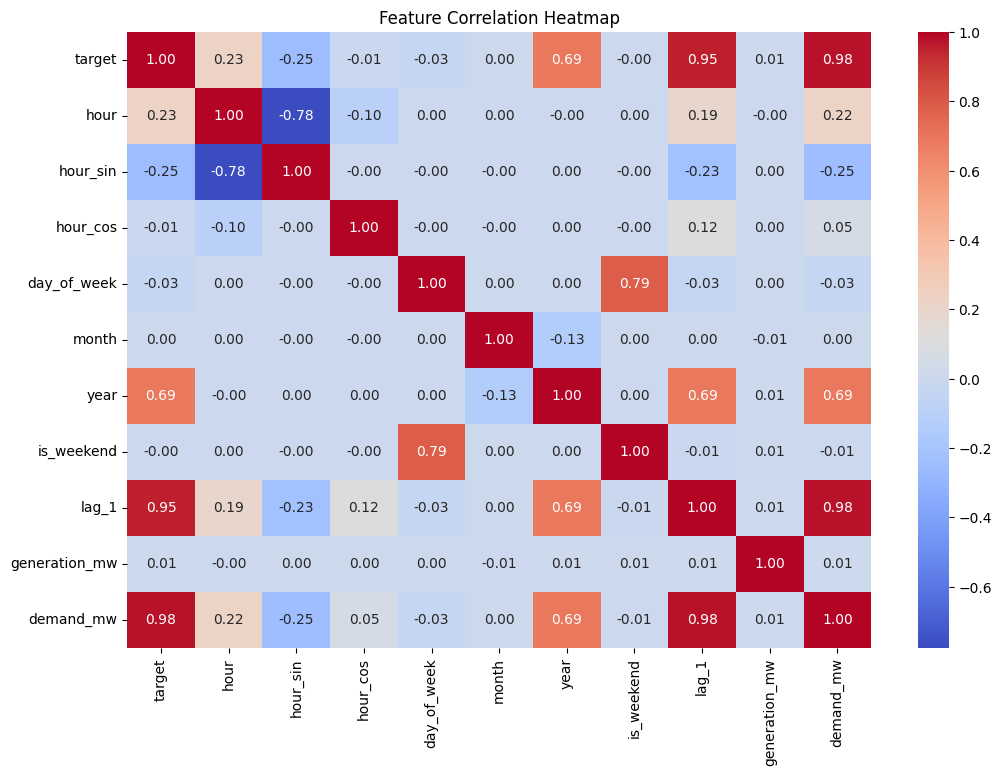

In [1410]:
cols = ['target', 'hour' ,'hour_sin', 'hour_cos','day_of_week', 'month', 'year', 'is_weekend', 'lag_1' , 'generation_mw', 'demand_mw'] 

plt.figure(figsize=(12, 8))
sns.heatmap(merged_df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [1411]:
import re
def clean_cols(cols):
    return [re.sub(r'_+', '_', re.sub(r'[^A-Za-z0-9_]', '_', col)).strip('_') for col in cols]

train_fit_df.columns = clean_cols(train_fit_df.columns)
test_df.columns  = clean_cols(test_df.columns)

feature_cols = clean_cols(feature_cols)
train_fit_df.columns = clean_cols(train_fit_df.columns)


In [1412]:
print(train_fit_df.columns.tolist())

['timestamp', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'time', 'temperature_2m_C', 'relative_humidity_2m', 'apparent_temperature_C', 'precipitation_mm', 'dew_point_2m_C', 'soil_temperature_0_to_7cm_C', 'wind_direction_10m', 'cloud_cover', 'sunshine_duration_s', 'year', 'Urban_population', 'Inflation_consumer_prices_annual', 'Electricity_production_from_renewable_sources_excluding_hydroelectric_kWh', 'Electricity_production_from_natural_gas_sources_of_total', 'Electricity_production_from_coal_sources_of_total', 'Value_lost_due_to_electrical_outages_of_sales_for_affected_firms', 'Energy_use_kg_of_oil_equivalent_per_capita', 'Fossil_fuel_energy_consumption_of_total', 'Access_to_electricity_of_population', 'Population_total', 'GDP_growth_annual', 'GDP_current_US', 'Industry_including_construction_value_added_of_GDP', 'Electricity_production_from_renewable_sources_e

## Model Training + Prediction

## RF

Test MAPE: 2.92%


C:\Users\User\AppData\Local\Temp\ipykernel_17256\949032542.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


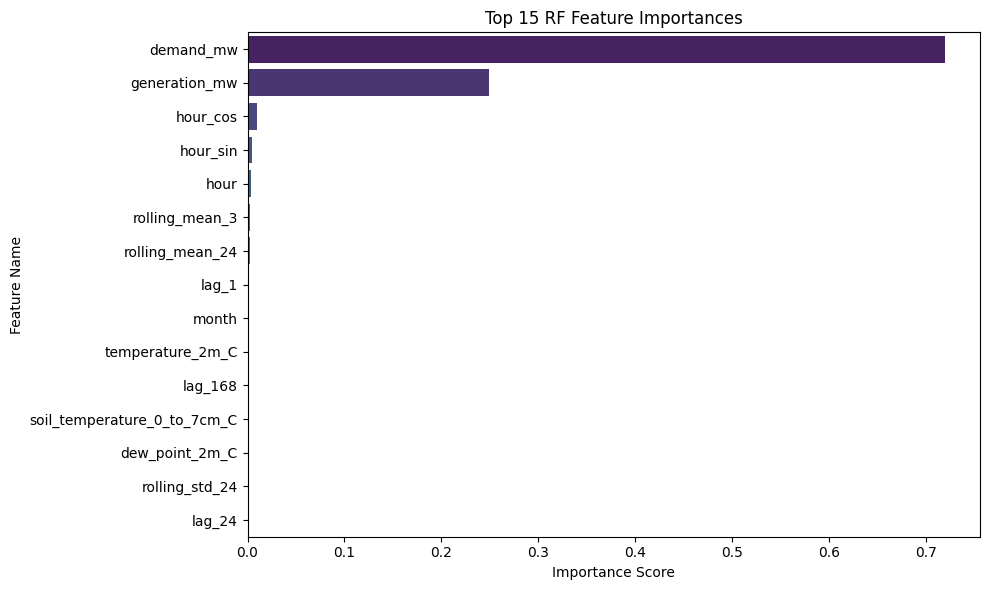

In [1413]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

X_train_fit = train_fit_df[feature_cols]
y_train_fit = train_fit_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_fit, y_train_fit)
pred = rf_model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, pred) * 100
print(f"Test MAPE: {mape:.2f}%")

feature_importance_df = pd.DataFrame({
    'Feature': X_train_fit.columns, 
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 RF Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## XGB

Test MAPE: 2.86%
demand_mw                                                                         0.530654
generation_mw                                                                     0.291925
lag_1                                                                             0.096435
hour_cos                                                                          0.015007
load_shedding                                                                     0.007662
hour_sin                                                                          0.007609
hour                                                                              0.006781
rolling_mean_24                                                                   0.004483
GDP_current_US                                                                    0.003996
lag_24                                                                            0.003957
rolling_mean_3                                                           

C:\Users\User\AppData\Local\Temp\ipykernel_17256\4113516142.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


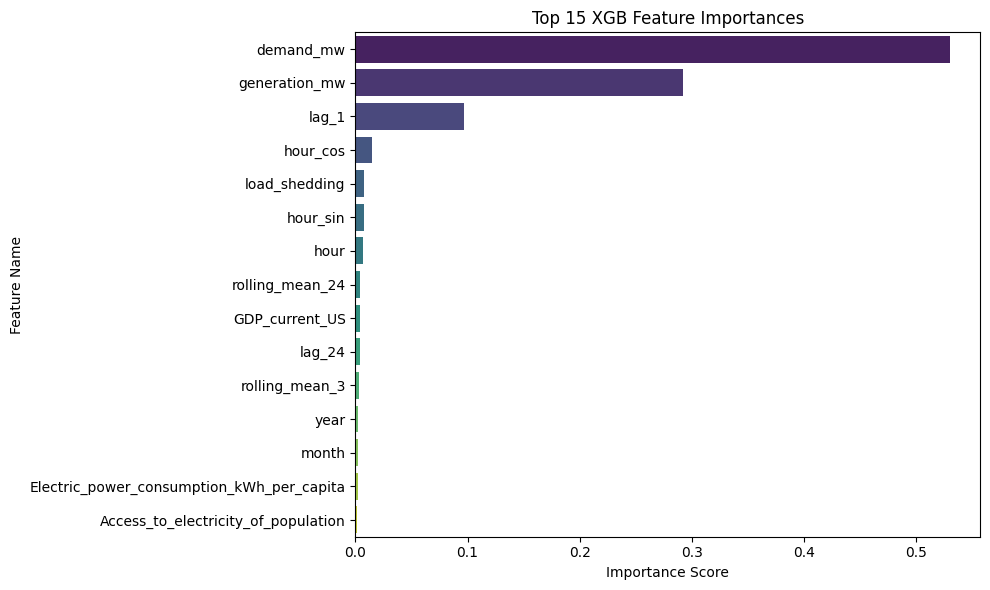

In [1414]:
import xgboost as xgb

X_train_fit = train_fit_df[feature_cols]
y_train_fit = train_fit_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,     
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist",
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train_fit, y_train_fit)
pred = xgb_model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, pred) * 100
print(f"Test MAPE: {mape:.2f}%")

importance_df = pd.Series(
    xgb_model.feature_importances_, 
    index=feature_cols
).sort_values(ascending=False)
print(importance_df)

feature_importance_df = pd.DataFrame({'Feature': X_train_fit.columns, 'Importance': xgb_model.feature_importances_}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 XGB Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


In [1415]:
low_imp_cols = importance_df[importance_df < 1e-4].index.tolist()
feature_cols_model = [c for c in feature_cols if c not in low_imp_cols]
X_train_fit = train_fit_df[feature_cols_model]
y_train_fit = train_fit_df['target']

X_test      = test_df[feature_cols_model]
y_test      = test_df['target']

xgb_model1 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model1.fit(
   X_train_fit, y_train_fit
)

predictions = xgb_model1.predict(X_test)
mape_score = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"Test MAPE: {mape_score:.2f}%")

Test MAPE: 2.84%


## LGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4336
[LightGBM] [Info] Number of data points in the train set: 76128, number of used features: 40
[LightGBM] [Info] Start training from score 8306.868738
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

C:\Users\User\AppData\Local\Temp\ipykernel_17256\2227057926.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


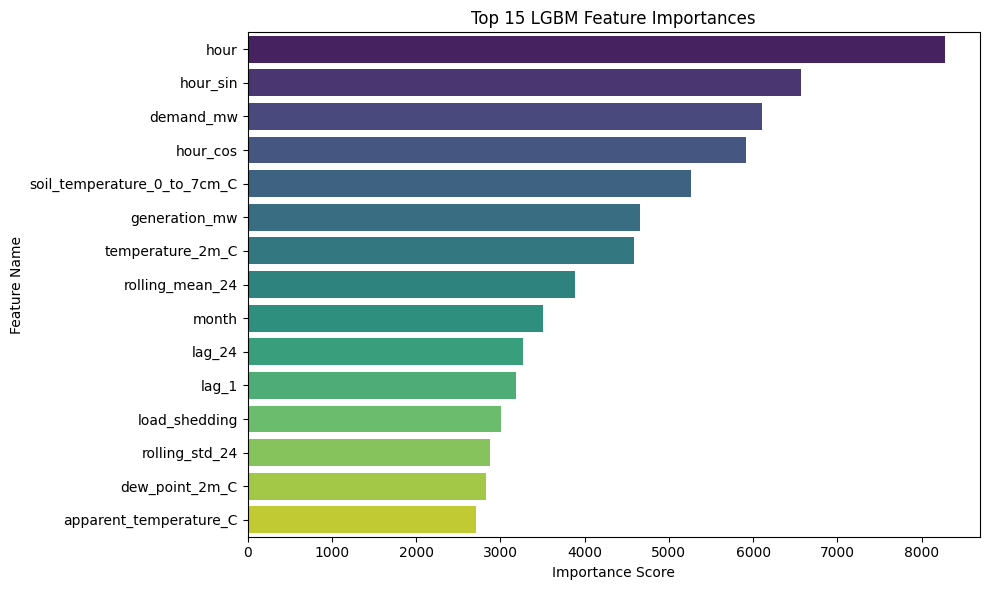

In [1416]:
from lightgbm import LGBMRegressor, log_evaluation, early_stopping

lgbm_model = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,       
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit( X_train_fit, y_train_fit )

predictions = lgbm_model.predict(X_test)
mape_score = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"Test MAPE: {mape_score:.2f}%")

importance_df = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train_fit.columns  
).sort_values(ascending=False)

print(importance_df)

feature_importance_df = pd.DataFrame({'Feature': X_train_fit.columns, 'Importance': lgbm_model.feature_importances_}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 LGBM Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## CAT

0:	learn: 2257.1072343	total: 21.3ms	remaining: 10.6s
100:	learn: 347.4472833	total: 1.05s	remaining: 4.17s
200:	learn: 303.9099340	total: 2s	remaining: 2.98s
300:	learn: 287.6933762	total: 2.94s	remaining: 1.94s
400:	learn: 275.6754816	total: 3.79s	remaining: 936ms
499:	learn: 266.5576176	total: 4.69s	remaining: 0us
Test MAPE: 2.78%
demand_mw                                                                         43.520252
generation_mw                                                                     32.962369
hour_sin                                                                           5.960420
hour_cos                                                                           5.061888
rolling_mean_24                                                                    2.597667
hour                                                                               2.386429
lag_1                                                                              1.508193
month               

C:\Users\User\AppData\Local\Temp\ipykernel_17256\2425359438.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


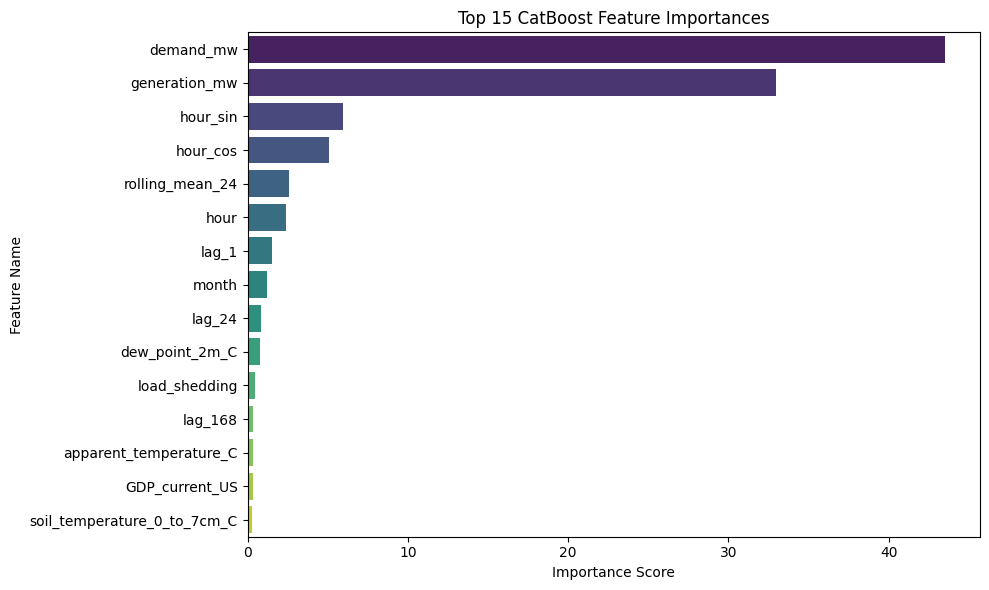

In [1417]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
     iterations=500,
     learning_rate=0.05,
     depth=6,
     verbose=100
)
cat_model.fit(X_train_fit, y_train_fit)

predictions = cat_model.predict(X_test)
mape_score = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"Test MAPE: {mape_score:.2f}%")

importance_df = pd.Series(
     cat_model.get_feature_importance(),
     index=X_train_fit.columns
).sort_values(ascending=False)

print(importance_df)

feature_importance_df = pd.DataFrame({
    'Feature': X_train_fit.columns, 
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 CatBoost Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [1418]:
for col in X_train_fit.columns:
    X_test[col] = X_test[col].astype(X_train_fit[col].dtype)
xgb_pred  = xgb_model1.predict(X_test)
lgbm_pred = lgbm_model.predict(X_test)
cat_pred = cat_model.predict(X_test)
ensemble = xgb_pred * 0.2 + lgbm_pred * 0.6 + cat_pred *0.2
mape = mean_absolute_percentage_error(y_test, ensemble) * 100
print(f"Ensemble MAPE: {mape:.2f}%")

C:\Users\User\AppData\Local\Temp\ipykernel_17256\1580421106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].astype(X_train_fit[col].dtype)


Ensemble MAPE: 2.63%


In [1419]:
from sklearn.linear_model import LinearRegression

p1 = xgb_model1.predict(X_test)
p2 = lgbm_model.predict(X_test)
p3 = cat_model.predict(X_test)

stacked_predictions = np.column_stack((p1, p2, p3))

meta_model = LinearRegression(positive=True)

meta_model.fit(stacked_predictions, y_test)

final_stack_pred = meta_model.predict(stacked_predictions)

stack_mape = mean_absolute_percentage_error(y_test, final_stack_pred) * 100
print(f"Stacking Meta-Learner MAPE: {stack_mape:.2f}%")

print("Model Weights (XGB, LGBM, Cat):", meta_model.coef_)




Stacking Meta-Learner MAPE: 2.54%
Model Weights (XGB, LGBM, Cat): [0.         0.76274635 0.26280704]


# REPORT OF THE NOTEBOOK - 

I made 3 dataframes from the given csv and xlsx files named demand_df, weather_df and econ_df. For the economic indicators, I selected 20 features manually by checking which feature sounded relevant for me. I finally transposed the econ_df which will be finally used to merge. I also made a column called timestamp for both demand_df and weather_df that will help to combine them and further feature making.

## 1. EDA + Data Preprocessing -
There were 160 duplicated values only in the demand_df, none other. As the size of the df was very huge so I dropped those duplicates which won't bring any significant changes in the prediction. Now I checked that what were the difference between the timestamps in consecutive rows. Ideally it should always be 0 day & 1 hr but it was not. For the half hourly gaps, I took the mean of the numeric cols and merged them and for other missing timestamps I forward filled them that is not supposed to cause any significant errors since there are few of them. Now I could merge to create the merged_df. For outliers in demand_mw, I plotted the box plots which makes the outliers clearly visible. Now i saw that using Z-score there were 4 less outliers than iqr, which is why I used iqr to remove them since it might cause trouble.



## 2. Feature Engineering + reason to engineer them
--1. hour, day_of_week, month and year all were made since the models cannot understand timestamp.

--2. is_weekend was made as in weekends the demand might be less as industries would be shut.

--3. lag features were made to capture the history of demand for the previous hours, day and week.

--4. rolling features were created to capture trend in demand

--5. hour_sin and hour_cos were created so that the model can understand that 0 hr comes after 23 hr

--6. adding the sin and cos for day and month would have been useful for neural networks but here it probably induces some noise    

--7. the target is next hour's demand.

--8. feature cols -> here I took some features that was giving the best result and commented out some that were misleading the models.


## 3. Model Training + Prediction
I trained the following models with their respective accuracies -

--1.Random Forest - 2.92%

--2.XGBoost - 2.86%

--3.XGBoost1 - 2.84%

--4.LGBM - 2.62%

--5.CATBoost - 2.78%

--6.Stacking(with linear regression over xgb1 + lgbm + cat) - 2.54% (Final Prediction)


*** I had tried the second model of xgb by removing some features that had low importance which only gave a slight improvement in the prediction.

*** I also was using validation for the year 2023 and training upto 2022 but that gave worse results as size of training set was decreasing.

*** We can see that boosting is giving better result than bagging,which is generally the case for most situations as it focuses on reducing mistakes.

## 4. Interpretation of feature importance
The features that imerged as most important were - 
--1.demand_mw - it is very certain that this will be having the top priority as in practical environment next hours demand = current hour's demand +/- error.

--2. generation_mw - it helps the model to understand if generated power is more or less than the demand.

--3. hour_sin & hour_cos - it helped the model to relate 11 pm with 0 am as their result is expected to be very close

--4. temperature - it is also clear that people often use more electricity in hotter temperature

--5. lag & rolling features - it helped the model to see the past history of demand across a day and week and also recognize the trend of demand.

*** These can be also visualised using the heatmap plotted earlier.